In [420]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

import category_encoders as ce      # 'category_encoders' is used for Binary Encoding

import warnings
warnings.filterwarnings('ignore')

In [421]:
df = pd.read_csv('house price prediction.csv')
print(df.columns)
df.head()

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [422]:
# changing column order
df = df[['date', 'statezip', 'city', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',  'price']]

# printing unique values
print(df.nunique())

print('\nSHAPE OF THE DATA : ', df.shape)
df.head()


date               70
statezip           77
city               44
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
price            1741
dtype: int64

SHAPE OF THE DATA :  (4600, 16)


,date,statezip,city,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,WA 98133,Shoreline,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,WA 98119,Seattle,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,WA 98042,Kent,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,WA 98008,Bellevue,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,WA 98052,Redmond,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


### **Approach for Feature Selection**


- OneHotEncoder - country
- For city we will be using Binary Encoder, applying One hot encoder on it will be messy
- Remove the 'WA' in statezip
- Covert date into date format



In [423]:
# applying Binary Encoder on 'city'
encoder = ce.BinaryEncoder(cols='city')        # make sure, here you must mention the feature name for which you want to use Binary Encoder

df = encoder.fit_transform(df)                 # keep in mind, BinaryEncoder only expects a pandas DataFrame, you cant put any list or array. Else will throw error
df.head()

,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,WA 98133,0,0,0,0,0,1,3.0,1.50,...,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,WA 98119,0,0,0,0,1,0,5.0,2.50,...,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,WA 98042,0,0,0,0,1,1,3.0,2.00,...,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,WA 98008,0,0,0,1,0,0,3.0,2.25,...,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,WA 98052,0,0,0,1,0,1,4.0,2.50,...,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [424]:
# removing 'WA' from all the values in 'statezip'

# df['statezip'] = df['statezip'].str.split().str[-1].astype(int)
df['statezip'] = df['statezip'].str.replace('WA', '')
# df['statezip'] = df['statezip'].astype('int')           # convering numbers into integers
df['statezip'] = df['statezip']        # dont convert zip into integers, coz for eg the model will consider  Zip 98133 is "greater" than Zip 98001

# print(df.info())
df.head()


,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,2014-05-02 00:00:00,98133,0,0,0,0,0,1,3.0,1.50,...,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,2014-05-02 00:00:00,98119,0,0,0,0,1,0,5.0,2.50,...,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,2014-05-02 00:00:00,98042,0,0,0,0,1,1,3.0,2.00,...,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,2014-05-02 00:00:00,98008,0,0,0,1,0,0,3.0,2.25,...,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,2014-05-02 00:00:00,98052,0,0,0,1,0,1,4.0,2.50,...,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [425]:
# applying datetime format on 'date'

df['date'] = pd.to_datetime(df['date'])     
# keep in mind, after converting it into datetime format, if you run this feature in linear reg, it will throw error
# hence you have to drop this feature. But if you drop this feature you would loose all the seasonal trends that how it affects the price
# to avoid this, you have to extract new features for day, month, and year


# day
df['day'] = df['date'].dt.dayofweek

# month
df['month'] = df['date'].dt.month

# year
df['year'] = df['date'].dt.year   



df.head()

,date,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,bathrooms,...,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price,day,month,year
0,2014-05-02,98133,0,0,0,0,0,1,3.0,1.50,...,0,3,1340,0,1955,2005,313000.0,4,5,2014
1,2014-05-02,98119,0,0,0,0,1,0,5.0,2.50,...,4,5,3370,280,1921,0,2384000.0,4,5,2014
2,2014-05-02,98042,0,0,0,0,1,1,3.0,2.00,...,0,4,1930,0,1966,0,342000.0,4,5,2014
3,2014-05-02,98008,0,0,0,1,0,0,3.0,2.25,...,0,4,1000,1000,1963,0,420000.0,4,5,2014
4,2014-05-02,98052,0,0,0,1,0,1,4.0,2.50,...,0,4,1140,800,1976,1992,550000.0,4,5,2014


In [426]:
df2 = df[['month', 'day', 'statezip', 'city_0', 'city_1', 'city_2', 'city_3', 'city_4', 'city_5', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'price']]
# since year and country are both constant feature adding no value, hence we have to remove them 


df2.head()

,month,day,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,5,4,98133,0,0,0,0,0,1,3.0,...,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,5,4,98119,0,0,0,0,1,0,5.0,...,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,5,4,98042,0,0,0,0,1,1,3.0,...,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,5,4,98008,0,0,0,1,0,0,3.0,...,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,5,4,98052,0,0,0,1,0,1,4.0,...,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [427]:
df2.corr()

,month,day,statezip,city_0,city_1,city_2,city_3,city_4,city_5,bedrooms,...,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
month,1.000000,-0.129538,-0.011539,0.002432,-0.014704,0.010923,0.018102,-0.003222,0.011469,0.010835,...,-0.023286,0.036890,0.007530,-0.011304,0.017695,0.042919,-0.011606,0.008488,-0.023882,0.041081
day,-0.129538,1.000000,-0.001291,0.016205,0.004703,-0.002121,0.004042,-0.003457,0.006196,0.015429,...,0.003533,-0.011327,-0.000292,0.032170,0.006317,0.013595,0.022538,0.006005,-0.019888,0.010847
statezip,-0.011539,-0.001291,1.000000,0.081060,-0.162155,-0.347660,-0.560359,0.282174,-0.176969,-0.153443,...,-0.133509,-0.064999,0.005937,0.095302,0.038038,-0.270585,0.064977,-0.356920,0.170387,-0.046052
city_0,0.002432,0.016205,0.081060,1.000000,-0.090675,-0.080389,0.054441,-0.007072,0.099007,-0.048664,...,0.145213,-0.039364,0.085915,0.048597,-0.001375,-0.015863,-0.042233,-0.026883,0.008194,-0.024055
city_1,-0.014704,0.004703,-0.162155,-0.090675,1.000000,0.009021,0.005425,-0.094826,0.183831,0.081590,...,0.104460,-0.003441,0.022896,-0.000752,-0.011699,0.148095,-0.040103,0.156731,-0.042419,-0.025226
city_2,0.010923,-0.002121,-0.347660,-0.080389,0.009021,1.000000,0.228213,-0.146603,0.142666,0.120829,...,0.036313,0.025491,0.022502,-0.021344,-0.034346,0.170578,-0.032550,0.233003,-0.083695,-0.012256
city_3,0.018102,0.004042,-0.560359,0.054441,0.005425,0.228213,1.000000,-0.406211,0.206014,0.134457,...,0.105982,0.024511,0.018301,0.001535,-0.059105,0.234202,0.001339,0.272627,-0.112140,0.083988
city_4,-0.003222,-0.003457,0.282174,-0.007072,-0.094826,-0.146603,-0.406211,1.000000,-0.250347,-0.141228,...,-0.062877,0.029993,-0.019904,0.000112,0.041779,-0.262871,0.005263,-0.208430,0.038886,-0.085123
city_5,0.011469,0.006196,-0.176969,0.099007,0.183831,0.142666,0.206014,-0.250347,1.000000,0.054225,...,0.098190,0.000140,0.044039,-0.039891,-0.065782,0.153652,-0.132859,0.277967,-0.091919,-0.093214
bedrooms,0.010835,0.015429,-0.153443,-0.048664,0.081590,0.120829,0.134457,-0.141228,0.054225,1.000000,...,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082,0.200336


In [428]:
X = df2.drop(columns=['price'])
y = df2['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = pd.DataFrame(lr.predict(X_test))

# y_pred


print(f"R2 SCORE : {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")




R2 SCORE : 0.06477348705254082
MAE : 185187.91980286082
MSE : 675656249490.062


In [429]:
X = df2.drop(columns=['price'])
y = df2['price']

std = StandardScaler()
X = std.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = pd.DataFrame(lr.predict(X_test))

# y_pred


print(f"R2 SCORE : {r2_score(y_test, y_pred)}")
print(f"MAE : {mean_absolute_error(y_test, y_pred)}")
print(f"MSE : {mean_squared_error(y_test, y_pred)}")




R2 SCORE : 0.03557690804940017
MAE : 198635.45304358783
MSE : 983563360621.1637


### **Removing Outliers**

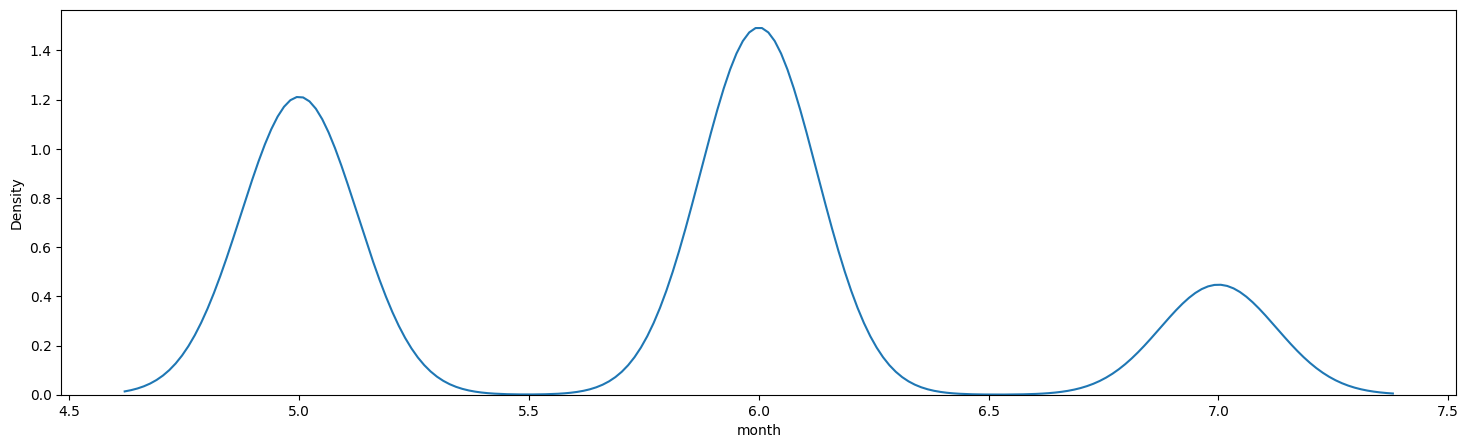

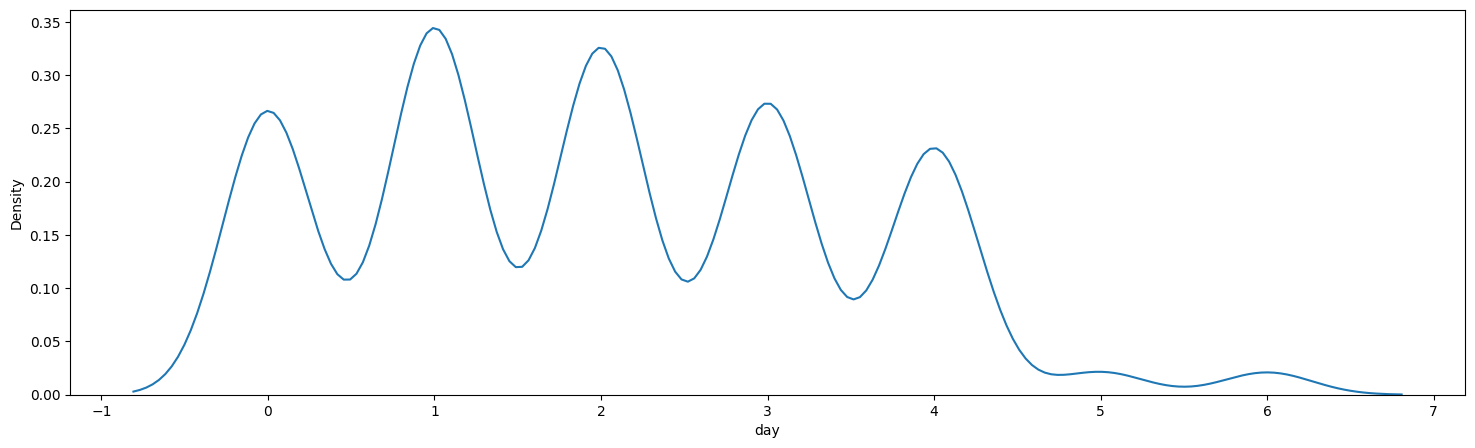

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

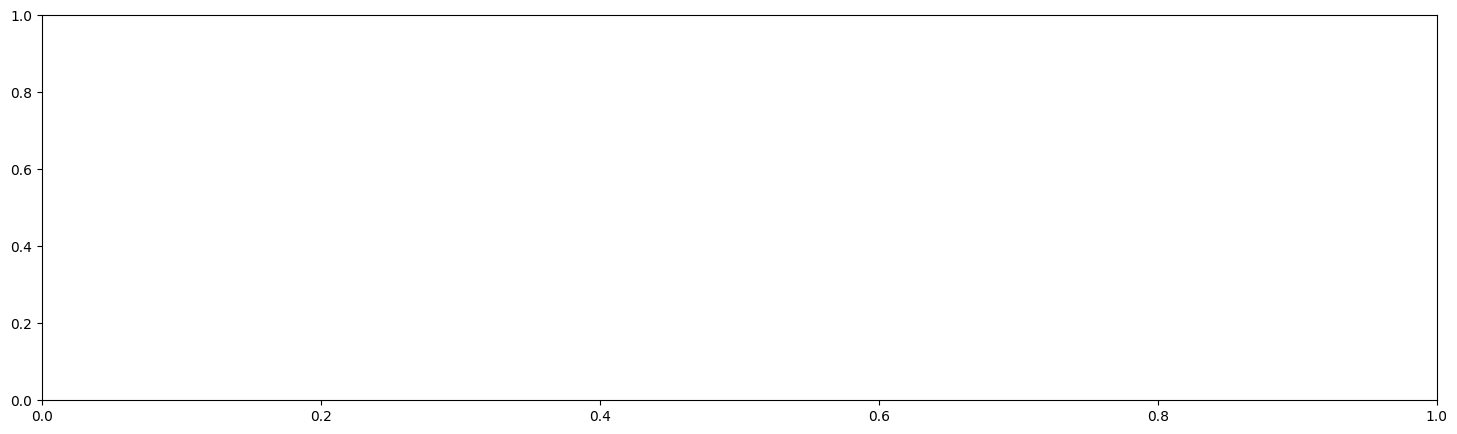

In [435]:
for i in df2.columns:
    plt.figure(figsize=(18, 5))
    sns.kdeplot(df[i])

    plt.show()